### Tutorial 05: Bounce Decomposition

In [17]:
import bpy
import numpy as np
import matplotlib.pyplot as plt
import import_ipynb

from L001_hello_world import render, clear_scene

# Clear scene
if __name__ == '__main__':
    clear_scene()

    filepath = './scenes/cornell_box.blend'
    bpy.ops.wm.open_mainfile(filepath=filepath)

13:49.472  blend            | Read blend: "/Users/motoole/git/computational-imaging-lessons/scenes/cornell_box.blend"


In [18]:
node_group = bpy.data.node_groups.new(name='LightBounceNodeGroup', type='ShaderNodeTree')
node_group.interface.new_socket(name='BSDF', in_out='INPUT',  socket_type='NodeSocketShader')
node_group.interface.new_socket(name='BSDF', in_out='OUTPUT', socket_type='NodeSocketShader')

node1 = node_group.nodes.new('ShaderNodeLightPath')
node1.location = (0, 0)

node2 = node_group.nodes.new('ShaderNodeMath')
node2.location = (200, 0)
node2.operation = 'COMPARE'

node3 = node_group.nodes.new('NodeGroupInput')
node3.location = (400, 0)

node4 = node_group.nodes.new('ShaderNodeMixShader')
node4.location = (600, 0)

node5 = node_group.nodes.new('NodeGroupOutput')
node5.location = (800, 0)

node_group.links.new(node1.outputs['Ray Depth'], node2.inputs[1])
node_group.links.new(node2.outputs[0], node4.inputs[0])
node_group.links.new(node3.outputs[0], node4.inputs[2])
node_group.links.new(node4.outputs[0], node5.inputs[0])

node2.inputs[0].default_value = 0
node2.inputs[2].default_value = 0.1

In [19]:
material = bpy.data.materials.get("Emissive Material")

if material:
    node_tree = material.node_tree

    # Find the Material Output node
    material_output_node = next(
        (node for node in node_tree.nodes
         if node.bl_idname == "ShaderNodeOutputMaterial"),
        None
    )

    if material_output_node:
        # Find the shader connected to the Surface input
        surface_link = next(
            (link for link in node_tree.links
             if link.to_node == material_output_node
             and link.to_socket.name == "Surface"),
            None
        )

        if surface_link:
            existing_shader_socket = surface_link.from_socket

            # Create LightBounce node group
            group_node = node_tree.nodes.new("ShaderNodeGroup")
            group_node.node_tree = bpy.data.node_groups["LightBounceNodeGroup"]
            group_node.location = (
                material_output_node.location.x - 100,
                material_output_node.location.y - 200
            )

            # Replace the existing connection
            node_tree.links.remove(surface_link)

            node_tree.links.new(
                existing_shader_socket,
                group_node.inputs[0]
            )

            node_tree.links.new(
                group_node.outputs[0],
                material_output_node.inputs["Surface"]
            )

            print("Added LightBounce node to Emissive Material.")

Added LightBounce node to Emissive Material.


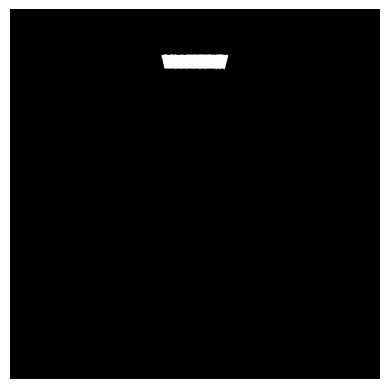

In [20]:
if __name__ == '__main__':
    node2.inputs[0].default_value = 0
    plt.imshow(render(), origin='lower')
    plt.axis('off')

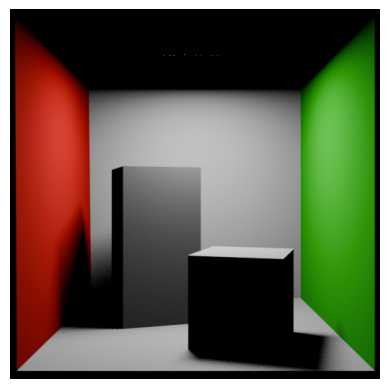

In [21]:
if __name__ == '__main__':
    node2.inputs[0].default_value = 1
    plt.imshow(render(), origin='lower')
    plt.axis('off')

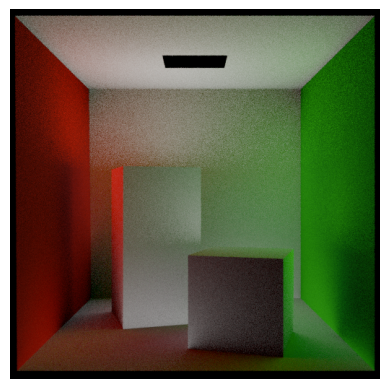

In [22]:
if __name__ == '__main__':
    node2.inputs[0].default_value = 2
    plt.imshow(render(), origin='lower')
    plt.axis('off')

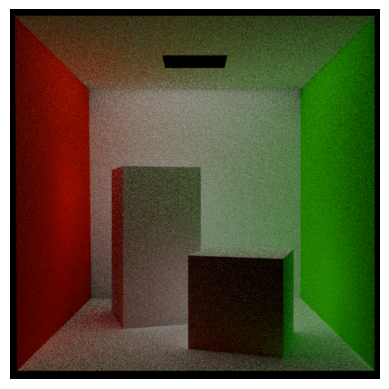

In [23]:
if __name__ == '__main__':
    node2.inputs[0].default_value = 3
    plt.imshow(render(), origin='lower')
    plt.axis('off')